In [ ]:
!pip install torch>=2.0.0 transformers>=4.35.0 numpy>=1.24.0 matplotlib>=3.7.0 seaborn>=0.12.0


In [51]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer


In [52]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device).eval()
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
text = "The Eiffel Tower is located in Paris"
inputs = tokenizer(text, return_tensors="pt").to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [54]:

# -------------------------------------------------------------------
# Helper: compute sink (first-token attention) for a given layer
# -------------------------------------------------------------------
def compute_sink_for_layer(layer_idx, hidden_states):
    attn = model.transformer.h[layer_idx].attn
    qkv = attn.c_attn(hidden_states)
    qkv = qkv.split(attn.split_size, dim=2)
    q, k, v = qkv[0], qkv[1], qkv[2]
    
    def reshape(x):
        return x.view(x.size(0), x.size(1), attn.num_heads, attn.head_dim).transpose(1, 2)
    
    q, k = reshape(q), reshape(k)
    
    # Baseline
    logits = torch.matmul(q, k.transpose(-2, -1)) / (k.size(-1) ** 0.5)
    probs = F.softmax(logits[:, :, -1, :], dim=-1)
    sink_base = probs[:, :, 0].mean().item()
    
    # KeyNorm
    q_norm = F.normalize(q, p=2, dim=-1)
    k_norm = F.normalize(k, p=2, dim=-1)
    logits_kn = torch.matmul(q_norm, k_norm.transpose(-2, -1)) / (k.size(-1) ** 0.5)
    probs_kn = F.softmax(logits_kn[:, :, -1, :], dim=-1)
    sink_kn = probs_kn[:, :, 0].mean().item()
    
    # Also return probability vector for heatmaps (last query, average over heads)
    prob_map_base = probs[0].mean(dim=0).detach().cpu().numpy()
    prob_map_kn   = probs_kn[0].mean(dim=0).detach().cpu().numpy()
    
    return sink_base, sink_kn, prob_map_base, prob_map_kn

In [55]:
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True)
    hidden_states = out.hidden_states  # tuple: [embedding, layer0...layer11]

sinks_base = []
sinks_kn = []
prob_maps_base = []
prob_maps_kn = []

for i in range(12):
    base, kn, pm_base, pm_kn = compute_sink_for_layer(i, hidden_states[i+1])
    sinks_base.append(base)
    sinks_kn.append(kn)
    prob_maps_base.append(pm_base)
    prob_maps_kn.append(pm_kn)

In [56]:
# -------------------------------------------------------------------
# Print average sink
# -------------------------------------------------------------------
print(f"Average sink across 12 layers – Baseline: {sum(sinks_base)/12:.4f}")
print(f"Average sink across 12 layers – KeyNorm:  {sum(sinks_kn)/12:.4f}")

Average sink across 12 layers – Baseline: 0.8125
Average sink across 12 layers – KeyNorm:  0.1152


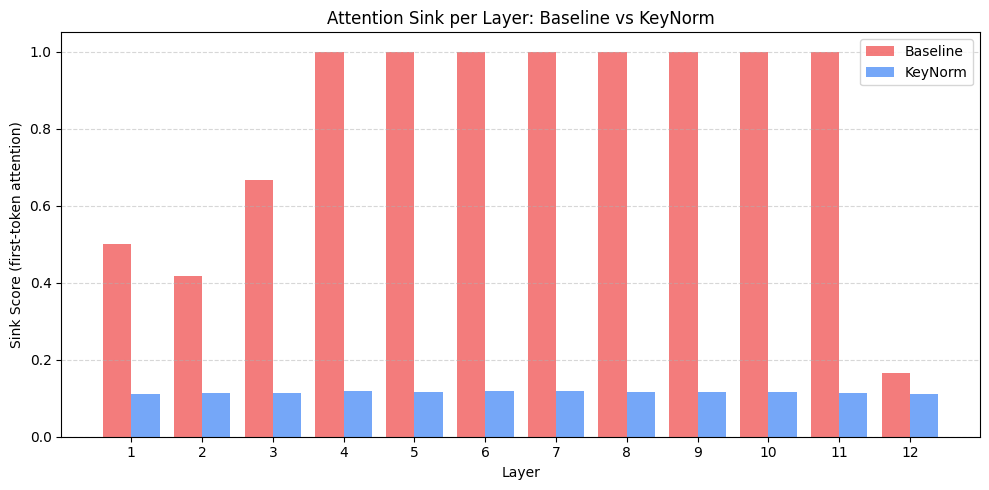

In [57]:

# -------------------------------------------------------------------
# PLOT 1: Per-layer bar chart
# -------------------------------------------------------------------
plt.figure(figsize=(10,5))
layers = range(1,13)
plt.bar(layers, sinks_base, width=0.4, label='Baseline', color='#ef4444', alpha=0.7)
plt.bar([l+0.4 for l in layers], sinks_kn, width=0.4, label='KeyNorm', color='#3b82f6', alpha=0.7)
plt.xlabel('Layer')
plt.ylabel('Sink Score (first-token attention)')
plt.title('Attention Sink per Layer: Baseline vs KeyNorm')
plt.xticks([l+0.2 for l in layers], layers)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('sink_per_layer.png', dpi=150)
plt.show()

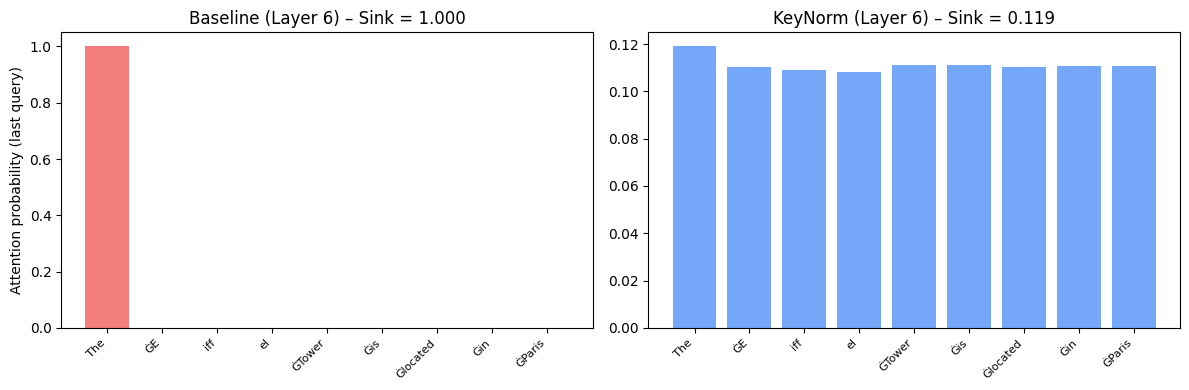

In [58]:
# -------------------------------------------------------------------
# PLOT 2: Heatmap (Layer 5, last query) – bar chart per token
# -------------------------------------------------------------------
layer_idx = 5  # 0-indexed, so layer 6 in 1-indexed
seq_len = len(prob_maps_base[layer_idx])
tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(seq_len), prob_maps_base[layer_idx], color='#ef4444', alpha=0.7)
ax1.set_title(f'Baseline (Layer {layer_idx+1}) – Sink = {sinks_base[layer_idx]:.3f}')
ax1.set_xticks(range(seq_len))
ax1.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Attention probability (last query)')
ax2.bar(range(seq_len), prob_maps_kn[layer_idx], color='#3b82f6', alpha=0.7)
ax2.set_title(f'KeyNorm (Layer {layer_idx+1}) – Sink = {sinks_kn[layer_idx]:.3f}')
ax2.set_xticks(range(seq_len))
ax2.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_layer5.png', dpi=150)
plt.show()